# Aproksymacja liniowa

***Zadanie 1.***

Zdefiniuj funkcję liniową z dowolnymi paramterami $a,b$. Przeprowadź symulację zaszumionego próbkowania jej wartości z przedziału [0,50]. Wykreśl funkcję wraz z jej zaszumionymi próbkami, a następnie dokonaj aproskymacji swojej funkcji za pomocą:
* funkcji liniowej,
* funkcji kwadratowej,
* wielomianu trzeciego stopnia.

Zastosuj metodę/metody minimalizujące najmniejszych kwadratów (normę średniokwadratową np. funkcję *curve_fit* z [SciPy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)).

Porównaj otrzymane wyniki z metodami interpolacji poznanymi na poprzednich zajęciach. W tym celu przeprowadź interpolację wygenerowanych danych za pomocą wielomianu interpolacyjnego Lagrange'a oraz za pomocą funkcji sklejanych.

*Wskazówka*: Najpierw wygerneruj tablicę 100 wartości $(x_i, f(x_i))$ dla $x_i \in [0,50]$. Następnie za pomocą np. funkcji *np.random.normal* wygeneruj 100-elementową tablicę szumu losowego i dodaj ją do wygenerowanych **wartości** funkcji (tj. do $f(x_i)$).

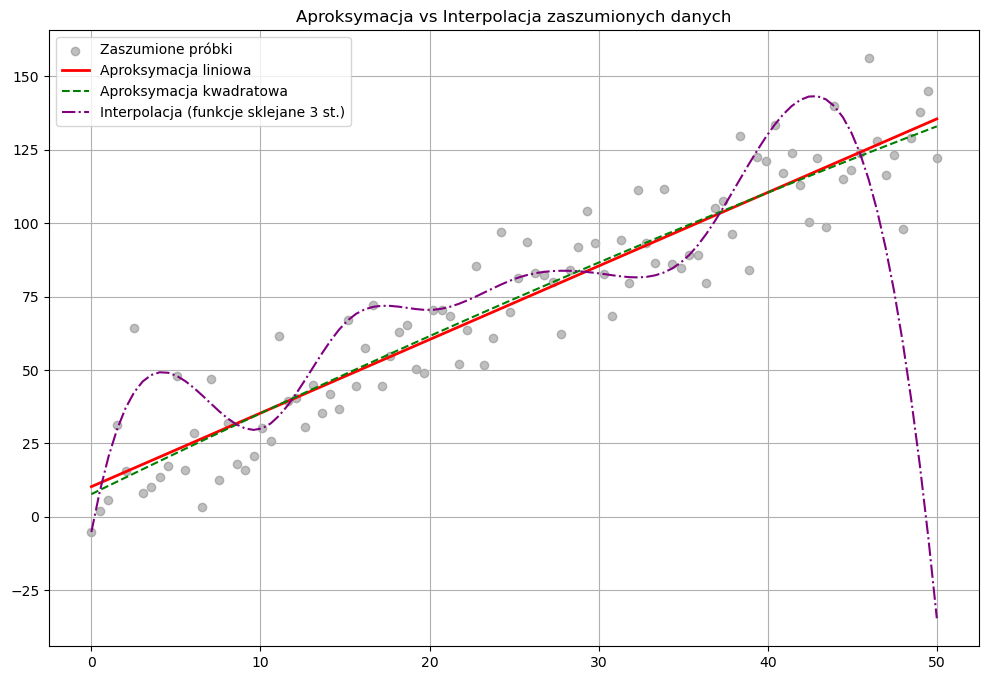

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import lagrange, interp1d

# 1. Definicja i generowanie danych
x = np.linspace(0, 50, 100)
a_true, b_true = 2.5, 10.0
y_true = a_true * x + b_true
y_noisy = y_true + np.random.normal(0, 15, 100) # Zaszumione próbki

# 2. Definicje funkcji do aproksymacji 
def func_lin(x, a, b): return a * x + b
def func_quad(x, a, b, c): return a * x**2 + b * x + c
def func_cube(x, a, b, c, d): return a * x**3 + b * x**2 + c * x + d

# Dopasowanie najmniejszymi kwadratami
popt_lin, _ = curve_fit(func_lin, x, y_noisy)
popt_quad, _ = curve_fit(func_quad, x, y_noisy)
popt_cube, _ = curve_fit(func_cube, x, y_noisy)

# 3. Interpolacja 
x_sparse = x[::10]
y_sparse = y_noisy[::10]
poly_lagrange = lagrange(x_sparse, y_sparse)
spline = interp1d(x_sparse, y_sparse, kind='cubic', fill_value="extrapolate")

# 4. Wykresy
plt.figure(figsize=(12, 8))
plt.scatter(x, y_noisy, label='Zaszumione próbki', color='gray', alpha=0.5)
plt.plot(x, func_lin(x, *popt_lin), label='Aproksymacja liniowa', color='red', linewidth=2)
plt.plot(x, func_quad(x, *popt_quad), label='Aproksymacja kwadratowa', color='green', linestyle='--')
plt.plot(x, spline(x), label='Interpolacja (funkcje sklejane 3 st.)', color='purple', linestyle='-.')
plt.title('Aproksymacja vs Interpolacja zaszumionych danych')
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2.***


Wykorzystaj metody aproksymacji do rozwiązania zadania z kierowcą z poprzednich ćwiczeń.


Kierowca jadący z miasta A do miasta B, zauważywszy na drodze fotoradar, zaczął gwałtownie hamować. Przebieg jego położenia, zarejestrowany przez nawigację, pokazano w poniższej tabeli. Wiedząc, że radar znajduje się w punkcie o współrzędnej 79.6 m, oszacuj kiedy kierowca minął fotoradar (w tym celu skorzystaj z jednej z metod z laboratorium 3) oraz z jaką prędkością wtedy jechał (wykorzystaj relację drogi i prędkości znaną z fizyki). 

|czas \[s\]|położenie \[m\]|
|--|--|
|0.0|0.0|
|1.0|42.7|
|2.0|73.2|
|3.0|92.5|

***Zadanie 3.***


Spróbuj przeprowadzić regresję liniową (aproksymację funkcją liniową) na rzeczywistych danych (np. z repozytorium [UCI](https://archive.ics.uci.edu/ml/datasets.php?format=&task=reg&att=&area=&numAtt=&numIns=&type=&sort=nameUp&view=table)). Wykorzystaj stworzony model do predykcji. Dla ułatwienia możesz zastosować funkcję z biblioteki [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).